In this document we provide a basic geometric analysis of the steering vectors computed for the following DS specs:

- Dataset: Anthropic's
- Training prompts: 350 pairs
- Cathegories: All
- Requirements: Having computed the steering vecs regarding the previous specs


## **Cosine distances**
Cosine distances are computed between steering vectors of consectuives layers (but regarding the same concept). These are especially interesting since cosine distance does not depend on the norms of the two vectors it computes the distance of.

Since this graph contains 7 different concepts, we are able to extract a recurring pattern among these 7: starting from a peak, the distance decreases steadily and reaches a stable value between layers 15-28, and then spikes up again.

We give the following explaination: the abstract concept is still generic at early stages, and hence more difficult to compute. It is then pretty much stabilized in the central layers of the network, before increasing its variability again due to the fact that it has to be translated to a tangible concept in deeper layers, since we are getting closer to the generation of a new word.

In [1]:
## LOADING THE DATASETS
from pathlib import Path
from torch import load as torchload

ROOT_PATH = Path('').resolve().parent
STEERING_VECTORS_PATH = ROOT_PATH / 'steering-vectors' / 'meta-llama' / 'Llama-3.1-8B-Instruct'

extracting = (
    'coordinate-other-ais',
    'corrigible-neutral-HHH',
    'hallucination',
    'myopic-reward',
    'refusal',
    'survival-instinct',
    'sycophancy'
)

steering_vectors = {}
for key in extracting:
    steering_vectors[key] = torchload(STEERING_VECTORS_PATH / f'{key}.pt')

/Users/simone/miniconda3/envs/llm-steering/lib/python3.13/site-packages/scipy/spatial/distance.py:670: RuntimeWarning: invalid value encountered in scalar divide
  dist = 1.0 - uv / math.sqrt(uu * vv)


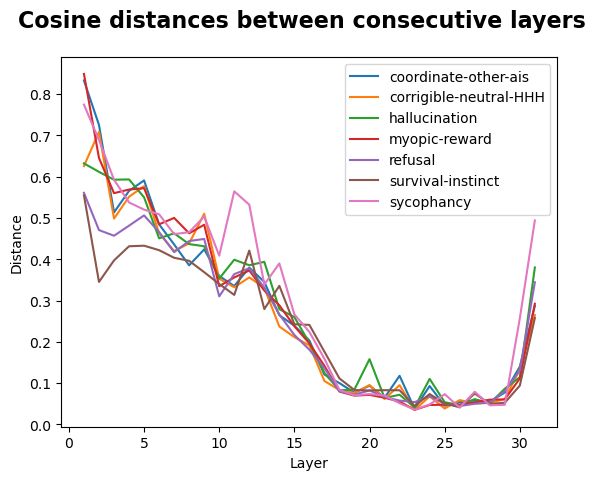

In [2]:
## VISUALIZING COSINE DISTANCES
from scipy.spatial.distance import cosine
import matplotlib.pyplot as plt
fig, ax = plt.subplots()


for key in extracting:
    current_cosine_distances = [] 
    
    for i,vec in enumerate(steering_vectors[key][1:]):
        current_cosine_distances.append(cosine(vec, steering_vectors[key][i]))
    ##

    ax.plot(current_cosine_distances, label=key)
##

ax.set_ylabel('Distance')
ax.set_xlabel('Layer')
ax.legend()
fig.suptitle(
    'Cosine distances between consecutive layers',
    fontweight='bold',
    fontsize=16
)
plt.show()

## **Norms**
We are still interested in understanding how the norm of such vectors change through different layers. 

Evidence suggests that the layer normalization is still not enough to show an increasing norm as we go deeper in the network. This is not a problem per sè, since the important goal of LayerNorm operations are to avoid gradient-vanishing phenomena. We do not test those. 

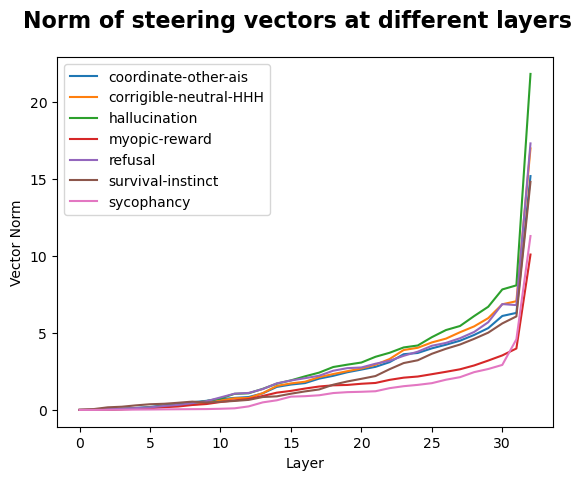

In [3]:
from numpy.linalg import norm
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
for key, vecs in steering_vectors.items():
    current_norms = []
    for vec in vecs:
        current_norms.append(norm(vec))
    ##
    ax.plot(current_norms, label=key)
##

ax.set_ylabel('Vector Norm')
ax.set_xlabel('Layer')
ax.legend()
fig.suptitle(
    'Norm of steering vectors at different layers',
    fontweight='bold',
    fontsize=16
)
plt.show()

## **Dimensionality reduction**
This is our strongest chance yet for our visualization purpose. Here we compute PCA and other dimensionality reduction techniques on the full steering vectors corpus. In that way we should be able to view a bit better the geometry of these steer. 

TODO: In this attempt we also try to obtain a raw embedding of these concepts.

Cumulative calculated variance: ~43.42%


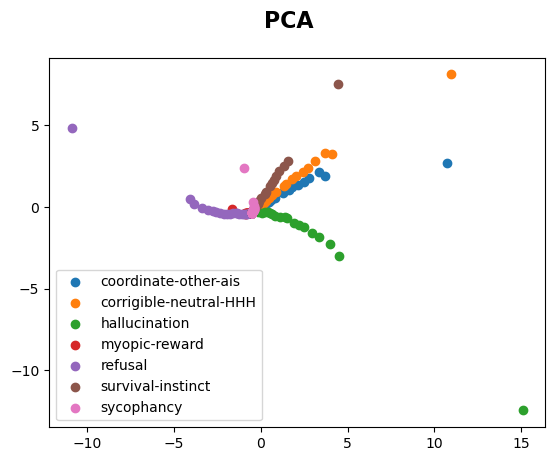

In [4]:
## PCA
from sklearn.decomposition import PCA
from torch import cat

pca = PCA(n_components=2)
all_vecs = cat([vec for vec in steering_vectors.values()], dim=0).numpy()

pca.fit(all_vecs)
pca_vecs = pca.transform(all_vecs)

fig, ax = plt.subplots()
print(f'Cumulative calculated variance: ~{sum(pca.explained_variance_ratio_)*100:.2f}%')

for i, key in enumerate(steering_vectors.keys()):

    x = pca_vecs.T[0, 33*i:33*(i+1)]
    y = pca_vecs.T[1, 33*i:33*(i+1)]
    ax.scatter(x, y, label=key)
    #ax.scatter(pca_vecs[33*i:33*(i+1)])

fig.suptitle('PCA', fontweight='bold', fontsize=16)
ax.legend()
plt.show()

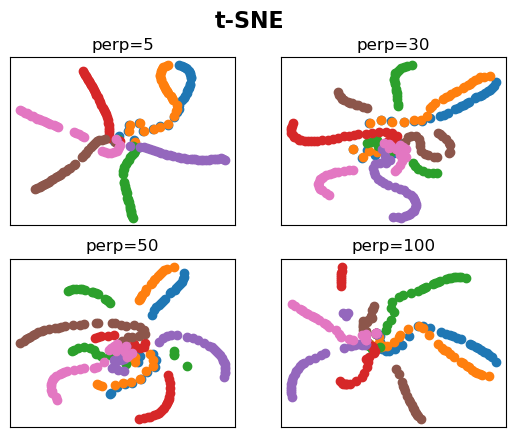

In [5]:
## t-SNE
from sklearn.manifold import TSNE

fig, ax = plt.subplots(ncols=2, nrows=2)
for perplexity, graph in zip([5, 30, 50, 100], ax.reshape(1,4)[0]):
    tsne_vecs = TSNE(n_components=2, perplexity=perplexity).fit_transform(all_vecs)

    for i, key in enumerate(steering_vectors.keys()):

        x = tsne_vecs.T[0, 33*i:33*(i+1)]
        y = tsne_vecs.T[1, 33*i:33*(i+1)]
        graph.scatter(x, y, label=key)
    
    graph.set_title(f'perp={perplexity}')
    graph.set_xticks([])
    graph.set_yticks([])

fig.suptitle('t-SNE', fontweight='bold', fontsize=16)
# fig.legend()
plt.show()

Great news is that the steering vectors appear distinguishable (at least with t-SNE), meaning that the steering vectors have absorbed the meaning across different layers.

PCA is probably not so effective since the norm at different layers is pretty informative and causes multiple linear dimensions to gain variance at a glance. As a consequence the first two dimensions are responsible of (only) the 32% of all the variance. That's not too bad, considering that we're using 4096-dimensional vectors!